<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Carregar o dataset Iris
iris = load_iris()

X = iris.data      # características
y = iris.target    # classes

# Divisão treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para teste
    random_state=42,    # reprodutibilidade
    stratify=y          # divisão estratificada
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (120, 4)
Tamanho do teste: (30, 4)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Carregar dataset
iris = load_iris()
X = iris.data
y = iris.target

# Divisão estratificada
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Criar modelo
modelo = DecisionTreeClassifier(random_state=42)

# Treinar modelo
modelo.fit(X_treino, y_treino)

# Previsões
y_pred_treino = modelo.predict(X_treino)
y_pred_teste = modelo.predict(X_teste)

# Calcular acurácia
acuracia_treino = accuracy_score(y_treino, y_pred_treino)
acuracia_teste = accuracy_score(y_teste, y_pred_teste)

print("Acurácia no treino:", acuracia_treino)
print("Acurácia no teste:", acuracia_teste)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

Atributo da raiz: pedal length (cm) <= 2.45
Profundidade da árvore: 5


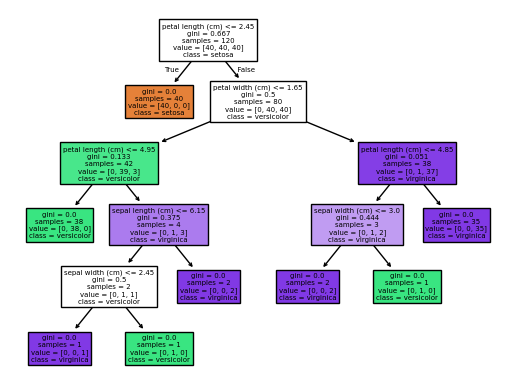

In [13]:
from sklearn.tree import plot_tree


plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

print("Atributo da raiz: pedal length (cm) <= 2.45")
print("Profundidade da árvore:", modelo.get_depth())

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

profundidades = [1,2,3,4,5,6,7,8,9,None]

print("max_depth | acc_treino | acc_teste | profundidade | folhas")

for d in profundidades:
    
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_treino, y_treino)

    # previsões
    pred_treino = modelo.predict(X_treino)
    pred_teste = modelo.predict(X_teste)

    # acurácia
    acc_treino = accuracy_score(y_treino, pred_treino)
    acc_teste = accuracy_score(y_teste, pred_teste)

    # propriedades da árvore
    profundidade = modelo.get_depth()
    folhas = modelo.get_n_leaves()

    print(d, "|", round(acc_treino,3), "|", round(acc_teste,3), "|", profundidade, "|", folhas)

max_depth | acc_treino | acc_teste | profundidade | folhas
1 | 0.667 | 0.667 | 1 | 2
2 | 0.967 | 0.933 | 2 | 3
3 | 0.983 | 0.967 | 3 | 5
4 | 0.992 | 0.933 | 4 | 7
5 | 1.0 | 0.933 | 5 | 8
6 | 1.0 | 0.933 | 5 | 8
7 | 1.0 | 0.933 | 5 | 8
8 | 1.0 | 0.933 | 5 | 8
9 | 1.0 | 0.933 | 5 | 8
None | 1.0 | 0.933 | 5 | 8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O Overfitting começa na profundidade 4, onde a acurácia do treino aumenta, porém a acurácia do teste cai.
Porque o algoritmo não está tendo um limite, dessa forma a árvore tem total liberdade para continuar se dividindo até isolar perfeitamente cada exemplo do conjunto de treinamento em sua própria folha.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

criterios = ["gini", "entropy"]

print("criterion | profundidade | acc_treino | acc_teste")

for c in criterios:

    modelo = DecisionTreeClassifier(criterion=c, random_state=42)
    modelo.fit(X_treino, y_treino)

    pred_treino = modelo.predict(X_treino)
    pred_teste = modelo.predict(X_teste)

    acc_treino = accuracy_score(y_treino, pred_treino)
    acc_teste = accuracy_score(y_teste, pred_teste)

    profundidade = modelo.get_depth()

    print(c, "|", profundidade, "|", round(acc_treino,3), "|", round(acc_teste,3))

criterion | profundidade | acc_treino | acc_teste
gini | 5 | 1.0 | 0.933
entropy | 5 | 1.0 | 0.933


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

profundidades = [1,2,3,4,5,6,7,8,9,None]

melhor_acc = 0
melhor_modelo = None
melhor_param = None

print("max_depth | acc_treino | acc_teste")

for d in profundidades:
    
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_treino, y_treino)

    pred_treino = modelo.predict(X_treino)
    pred_teste = modelo.predict(X_teste)

    acc_treino = accuracy_score(y_treino, pred_treino)
    acc_teste = accuracy_score(y_teste, pred_teste)

    print(d, "|", round(acc_treino,3), "|", round(acc_teste,3))

    if acc_teste > melhor_acc:
        melhor_acc = acc_teste
        melhor_modelo = modelo
        melhor_param = d
print("\nMelhor modelo encontrado:",melhor_modelo)
print("Profundidade com maior acurácia:", melhor_param, "\nCom acurácia de:", round(melhor_acc,3))

max_depth | acc_treino | acc_teste
1 | 0.667 | 0.667
2 | 0.967 | 0.933
3 | 0.983 | 0.967
4 | 0.992 | 0.933
5 | 1.0 | 0.933
6 | 1.0 | 0.933
7 | 1.0 | 0.933
8 | 1.0 | 0.933
9 | 1.0 | 0.933
None | 1.0 | 0.933

Melhor modelo encontrado: DecisionTreeClassifier(max_depth=3, random_state=42)
Profundidade com maior acurácia: 3 
Com acurácia de: 0.967


Ao usar o hiperparâmetro max_depth, que controla a profundidade da árvore, percebemos que conforme ela aumenta, a acurácia no treino também aumenta, pois o modelo se ajusta melhor aos dados. Porém, após certa profundidade, no caso após a profundidade 3, ocorre overfitting, quando o modelo passa a memorizar os dados de treino e a acurácia nos testes começa a diminuir conforme a profundidade aumenta.